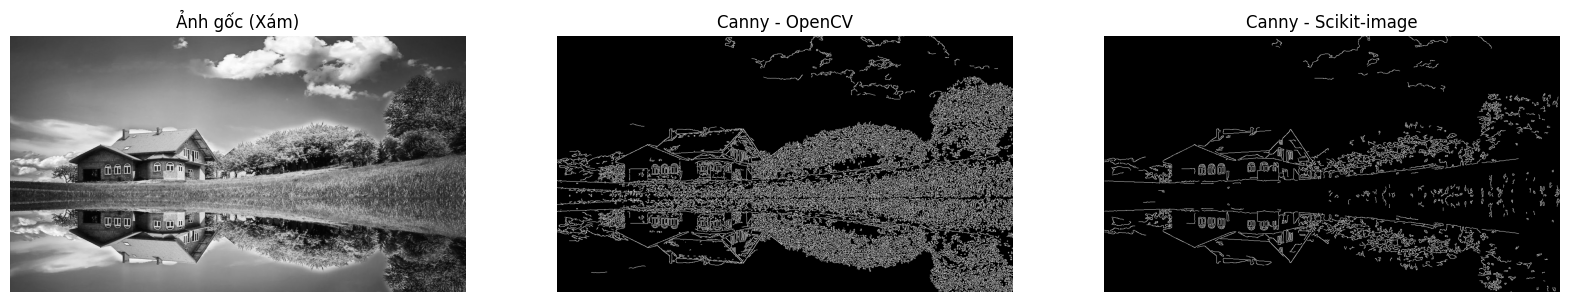

In [4]:
# Phần I. So sánh OpenCV và Scikit-image trong thuật toán Canny
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature

def show_images(titles, images):
    plt.figure(figsize=(20, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Đọc ảnh gốc ở chế độ Grayscale (Canny thường xử lý trên ảnh xám)
img_gray = cv2.imread('lab03.jpg', cv2.IMREAD_GRAYSCALE)

# 1. Thuật toán Canny bằng OpenCV
# Cú pháp: cv2.Canny(ảnh, ngưỡng_thấp, ngưỡng_cao)
edges_cv2 = cv2.Canny(img_gray, threshold1=100, threshold2=200)

# 2. Thuật toán Canny bằng Scikit-image
# Cú pháp: feature.canny(ảnh, sigma, ngưỡng_thấp, ngưỡng_cao)
# Lưu ý: skimage Canny trả về ma trận boolean (True/False), cần ép kiểu về float/uint8 để vẽ
edges_skimage = feature.canny(img_gray, sigma=1.0, low_threshold=100, high_threshold=200)

show_images(['Ảnh gốc (Xám)', 'Canny - OpenCV', 'Canny - Scikit-image'], 
            [img_gray, edges_cv2, edges_skimage.astype(float)])

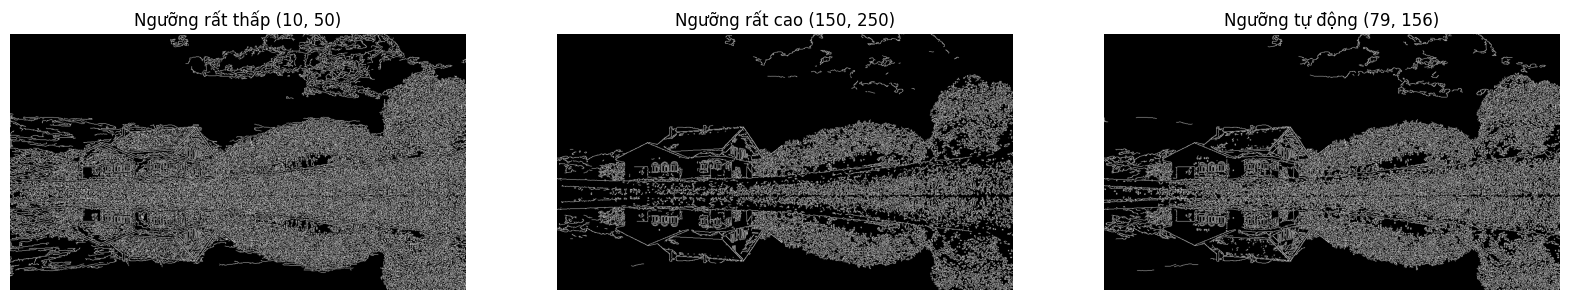

In [ ]:
# Phần 2. Thay đổi các tham số Threshold
# Thay đổi ngưỡng cao/thấp để xem sự khác biệt
# 1. Ngưỡng thấp (Bắt được nhiều cạnh yếu hơn, dễ lẫn nhiễu)
canny_low_thresh = cv2.Canny(img_gray, threshold1=10, threshold2=50)

# 2. Ngưỡng cao (Chỉ bắt các cạnh cực kỳ rõ nét, bỏ qua nhiều chi tiết)
canny_high_thresh = cv2.Canny(img_gray, threshold1=150, threshold2=250)

# 3. Kết hợp tính toán ngưỡng tự động (Auto Canny - Rất hay dùng trong thực tế)
median = np.median(img_gray)
lower = int(max(0, (1.0 - 0.33) * median))
upper = int(min(255, (1.0 + 0.33) * median))
canny_auto = cv2.Canny(img_gray, lower, upper)

show_images(['Ngưỡng rất thấp (10, 50)', 'Ngưỡng rất cao (150, 250)', f'Ngưỡng tự động ({lower}, {upper})'], 
            [canny_low_thresh, canny_high_thresh, canny_auto])

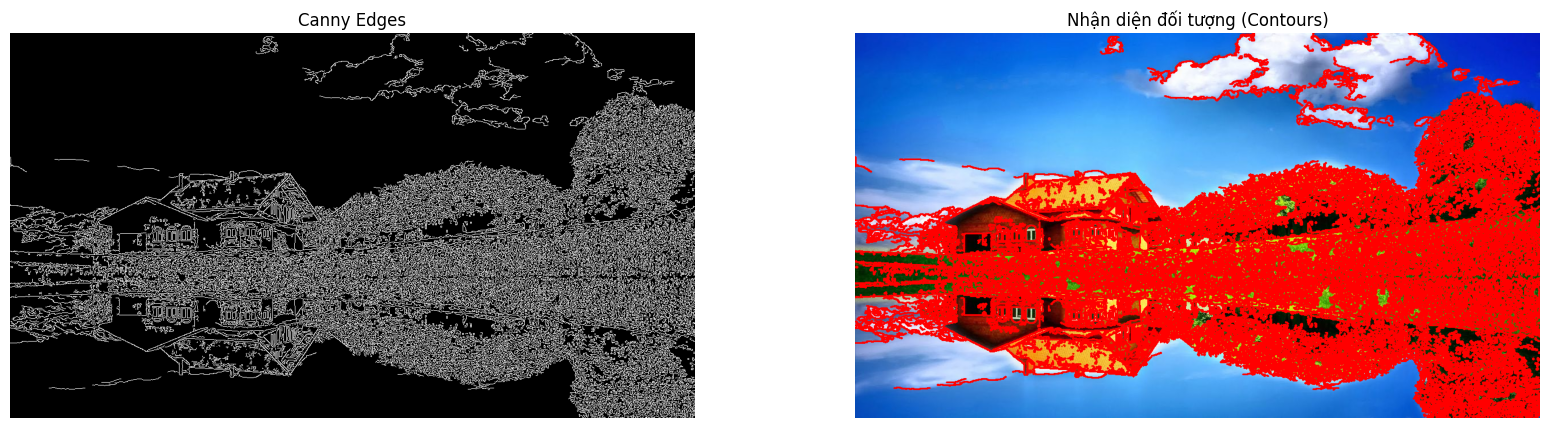

In [7]:
# Phần 3. Kết hợp Canny với nhận dạng hình dáng (Tìm Contours)
# Đọc ảnh màu để vẽ viền cho đẹp
img_color = cv2.imread('lab03.jpg')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Dùng Canny tìm cạnh trước
edges = cv2.Canny(img_gray, 50, 150)

# Tìm các đường viền (contours) dựa trên các cạnh Canny đã tìm được
# RETR_EXTERNAL: Chỉ lấy các viền ngoài cùng
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Vẽ các đường viền tìm được lên ảnh gốc (màu đỏ, độ dày 2)
img_contours = img_color.copy()
cv2.drawContours(img_contours, contours, -1, (255, 0, 0), 2)

show_images(['Canny Edges', 'Nhận diện đối tượng (Contours)'], [edges, img_contours])